# Comparaison de l'efficacité des joueurs RL classiques

In [1]:
#Imports
import sys
sys.path.append('../onitama/')
from players import HeuristicPlayer, RandomPlayer, LookAheadHeuristicPlayer, MCTSPlayer
from game import GameSession
import pickle


2026-02-21 11:14:46.356764: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-21 11:14:46.380971: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-21 11:14:48.582151: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-21 11:14:51.985938: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computat

In [84]:
#Configuration
players = {
    'random' : { 'class' : RandomPlayer(), 'name' : 'Joueur random', 'type' : 'random'},
    'heuristic_regular' : { 'class' : HeuristicPlayer(heuristic_function='heuristic_regular'), 'name' : 'Heuristique (regular)', 'type' : 'heuristic'},
    'heuristic_aggressive' : { 'class' : HeuristicPlayer(heuristic_function='heuristic_aggressive'), 'name' : 'Heuristique (aggressive)', 'type' : 'heuristic'},
    'heuristic_defensive' : { 'class' : HeuristicPlayer(heuristic_function='heuristic_defensive'), 'name' : 'Heuristique (defensive)', 'type' : 'heuristic'},
    'heuristic_mobility' : { 'class' : HeuristicPlayer(heuristic_function='heuristic_mobility'), 'name' : 'Heuristique (mobility)', 'type' : 'heuristic'},
    'heuristic_positional' : { 'class' : HeuristicPlayer(heuristic_function='heuristic_positional'), 'name' : 'Heuristique (positional)', 'type' : 'heuristic'},
     'heuristic_2lookahead_regular' : { 'class' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_regular'), 'name' : 'LookAhead2 heuristique (regular)', 'type' : 'heuristic2'},
    'heuristic_2lookahead_aggressive' : { 'class' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_aggressive'), 'name' : 'LookAhead2 heuristique (aggressive)', 'type' : 'heuristic2'},
    'heuristic_2lookahead_defensive' : { 'class' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_defensive'), 'name' : 'LookAhead2 heuristique (defensive)', 'type' : 'heuristic2'},
    'heuristic_2lookahead_mobility' : { 'class' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_mobility'), 'name' : 'LookAhead2 heuristique (mobility)', 'type' : 'heuristic2'},
    'heuristic_2lookahead_positional' : { 'class' : LookAheadHeuristicPlayer(max_depth=2, heuristic_function='heuristic_positional'), 'name' : 'LookAhead2 heuristique (positional)', 'type' : 'heuristic2'},
    'heuristic_3lookahead_regular' : { 'class' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_regular'), 'name' : 'LookAhead3 heuristique (regular)', 'type' : 'heuristic3'},
    'heuristic_3lookahead_aggressive' : { 'class' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_aggressive'), 'name' : 'LookAhead3 heuristique (aggressive)', 'type' : 'heuristic3'},
    'heuristic_3lookahead_defensive' : { 'class' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_defensive'), 'name' : 'LookAhead3 heuristique (defensive)', 'type' : 'heuristic3'},
    'heuristic_3lookahead_mobility' : { 'class' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_mobility'), 'name' : 'LookAhead3 heuristique (mobility)', 'type' : 'heuristic3'},
    'heuristic_3lookahead_positional' : { 'class' : LookAheadHeuristicPlayer(max_depth=3, heuristic_function='heuristic_positional'), 'name' : 'LookAhead3 heuristique (positional)', 'type' : 'heuristic3'},
    'mcts_1000' : { 'class' : MCTSPlayer(num_simulations=1000), 'name' : 'MCTS (1000)', 'type' : 'mcts'},
    'mcts_2000' : { 'class' : MCTSPlayer(num_simulations=2000), 'name' : 'MCTS (2000)', 'type' : 'mcts'},
}

type_colors = {
    'random' : 'grey',
    'heuristic' : 'deepskyblue',
    'heuristic2' : 'cornflowerblue',
    'heuristic3' : 'darkblue',
    'mcts' : 'gold'
}

In [3]:
#Résultats
resultats = {}

In [26]:
with open('resultats.pkl', 'rb') as f:
    resultats = pickle.load(f)

In [36]:


tested_player = 'mcts_1000'
nb_games = 100

if tested_player not in resultats:
    resultats[tested_player] = {}

for p in players:
    
    if p != tested_player and p not in resultats[tested_player]:
        print(f"Joueur {p}")
        p1 = players[tested_player]['class']
        p2 = players[p]['class']      
        gameSession = GameSession(player_one=p1, player_two=p2, number_of_games=nb_games)
        gameSession.start()

        stats = gameSession.getStats()
        
        resultats[tested_player][p] = {'win' : stats['p1_win'], 'draw' : stats['draw'], 'avg_time': stats['p1_avg_time']}



tested_player = 'mcts_2000'
nb_games = 100

if tested_player not in resultats:
    resultats[tested_player] = {}

for p in players:
    
    if p != tested_player and p not in resultats[tested_player]:
        print(f"Joueur {p}")
        p1 = players[tested_player]['class']
        p2 = players[p]['class']      
        gameSession = GameSession(player_one=p1, player_two=p2, number_of_games=nb_games)
        gameSession.start()

        stats = gameSession.getStats()
        
        resultats[tested_player][p] = {'win' : stats['p1_win'], 'draw' : stats['draw'], 'avg_time': stats['p1_avg_time']}


with open('resultats.pkl', 'wb') as f:
    pickle.dump(resultats, f)


Joueur heuristic_2lookahead_defensive


Games  : 100%|██████████| 100/100 [05:59<00:00,  3.59s/it]


Joueur heuristic_2lookahead_mobility


Games  : 100%|██████████| 100/100 [05:01<00:00,  3.02s/it]


Joueur heuristic_2lookahead_positional


...

Games  : 100%|██████████| 100/100 [18:14<00:00, 10.95s/it]


Joueur heuristic_3lookahead_positional


Games  : 100%|██████████| 100/100 [16:52<00:00, 10.12s/it]


Joueur mcts_1000


Games  : 100%|██████████| 100/100 [16:19<00:00,  9.80s/it]


In [37]:
with open('resultats.pkl', 'wb') as f:
    pickle.dump(resultats, f)

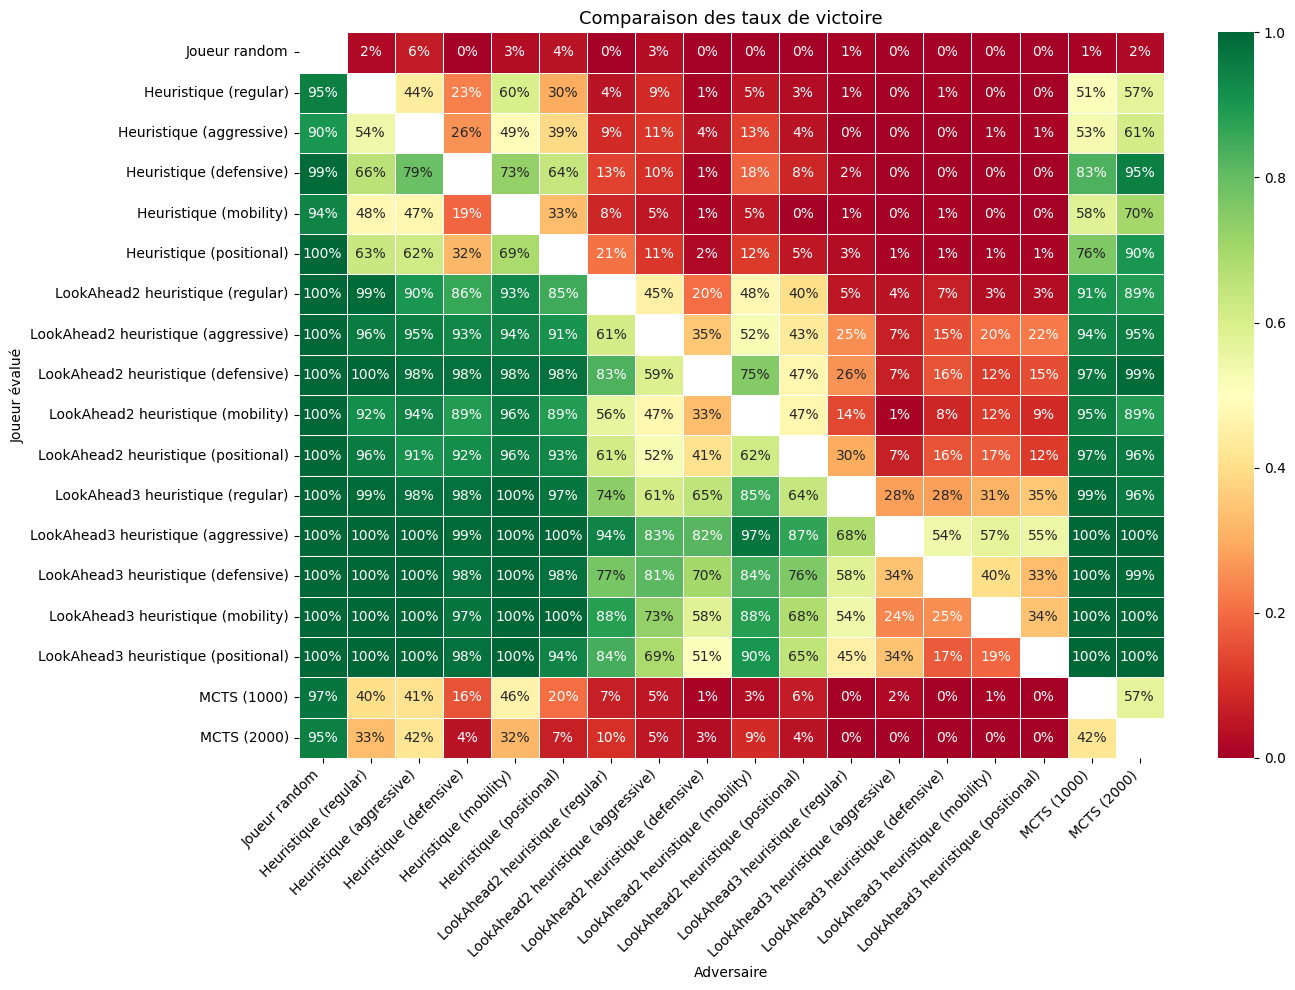

In [50]:
#Affichage d'une heatmap de comparaison des modèles

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Construction de la matric de taux de victoires
player_names = [players[p]['name'] for p in players]
matrix = pd.DataFrame(index=player_names, columns=player_names, dtype=float)

for p1 in players:
    p1_name = players[p1]['name']
    for p2 in players:
        p2_name = players[p2]['name']
        if p1 != p2:
            matrix.loc[p1_name, p2_name] = float(resultats[p1][p2]['win']/100)


#Affichage de la heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    matrix.astype(float),
    annot=True,
    fmt=".0%",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Comparaison des taux de victoire", fontsize=13)
ax.set_xlabel("Adversaire")
ax.set_ylabel("Joueur évalué")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



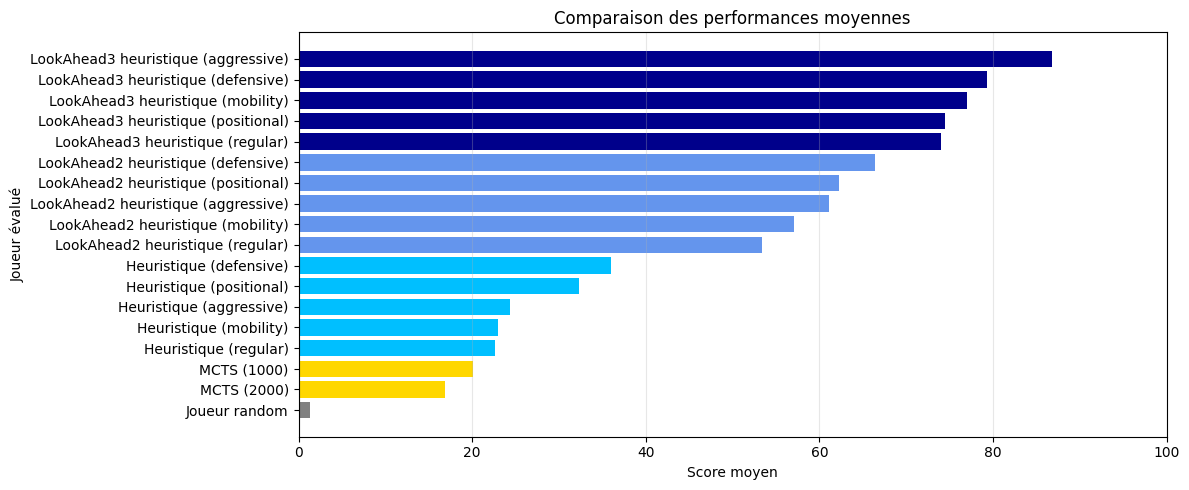

In [86]:
#Calcul du taux de victoire moyen

#Préparation des données
graphdata = pd.DataFrame(index=player_names, columns=["player", "avg_score", "color"])
for p in players:
    total = sum(resultats[p][p2]['win'] for p2 in resultats[p])/len(resultats[p])
    p_name = players[p]['name']
    graphdata.loc[p_name, 'player'] = p_name
    graphdata.loc[p_name, 'avg_score'] = total
    graphdata.loc[p_name, 'color'] = type_colors[players[p]['type']]

plt.figure(figsize=(12, 5))

graphdata = graphdata.sort_values('avg_score', ascending=True)

plt.barh(graphdata['player'], graphdata['avg_score'], color=graphdata['color'], alpha=1)
plt.xlabel('Score moyen')
plt.ylabel('Joueur évalué')
plt.title('Comparaison des performances moyennes')
plt.xlim(0, 100)  # Adapter selon vos valeurs
plt.grid(axis='x', alpha=0.3)


plt.tight_layout()
plt.show()


